In [2]:
import qiskit_aer

from ewfs.setting import SETTING_PAIRS
from ewfs.experiment import run_experiment
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = qiskit_aer.Aer.get_backend("aer_simulator")
backend = FakeFez()

run_experiment(
    shots=10_000,
    num_trials=1,
    charlie_sizes=range(1, 2),
    debbie_sizes=[0],
    strategy="majority_vote",
    friend_state="ghz",
    flag_size=6,
    backend=backend,
    settings=SETTING_PAIRS,
    save=True,
)

Trial 1 out of 1 for task of 1_0
Task with task ID: 7c7e150a-3ab1-42c2-8770-5e7e872efe5e

Processing trial 1 for task with task ID: 7c7e150a-3ab1-42c2-8770-5e7e872efe5e
Results: {('peek', 'peek'): {'1': 0.4896, '0': 0.5104}, ('peek', 'reverse_1'): {'00': 0.1049, '01': 0.4006, '10': 0.395, '11': 0.0995}, ('peek', 'reverse_2'): {'00': 0.3912, '11': 0.3882, '01': 0.1145, '10': 0.1061}, ('reverse_1', 'peek'): {'0': 0.5014, '1': 0.4986}, ('reverse_1', 'reverse_1'): {'00': 0.3727, '11': 0.3729, '01': 0.1276, '10': 0.1268}, ('reverse_1', 'reverse_2'): {'01': 0.4281, '10': 0.4314, '00': 0.0732, '11': 0.0673}, ('reverse_2', 'peek'): {'1': 0.5013, '0': 0.4987}, ('reverse_2', 'reverse_1'): {'10': 0.4022, '00': 0.1014, '01': 0.4024, '11': 0.094}, ('reverse_2', 'reverse_2'): {'10': 0.4073, '01': 0.4025, '00': 0.0979, '11': 0.0923}}
semi_brukner=0.3788 -- is violated: True
Violations: {'semi_brukner': 0.3788}

Post-processed results: defaultdict(<function run_experiment.<locals>.<lambda> at 0x11bc11

defaultdict(<function ewfs.experiment.run_experiment.<locals>.<lambda>()>,
            {'1_0': defaultdict(list, {'semi_brukner': [0.3788]})})

In [3]:
from ewfs.setting import SETTING_PAIRS
from ewfs.experiment import run_experiment

from qiskit_ibm_runtime import QiskitRuntimeService
 
QiskitRuntimeService.save_account(
  token="htVYX3nZDI5I1fSkYQw8Y0rddMrBi1eElvW8EHhy5D4q",
  name="farrokh",
  channel="ibm_quantum_platform",
  overwrite=True
)
service = QiskitRuntimeService(name="farrokh")
backend = service.backend("ibm_pittsburgh")


run_experiment(
    shots=10_000,
    num_trials=1,
    charlie_sizes=range(1, 2),
    debbie_sizes=[0],
    strategy="majority_vote",
    friend_state="ghz",
    flag_size=6,
    backend=backend,
    settings=SETTING_PAIRS,
    save=True,
)

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-08-20 14:31:50,712: Default instance not set. Searching all available instances.


Trial 1 out of 1 for task of 1_0
Task with task ID: d2is0olv7m7s73ec00l0

Processing trial 1 for task with task ID: d2is0olv7m7s73ec00l0
Results: {('peek', 'peek'): {'1': 0.4864, '0': 0.5136}, ('peek', 'reverse_1'): {'01': 0.3849, '10': 0.384, '00': 0.1288, '11': 0.1023}, ('peek', 'reverse_2'): {'10': 0.1093, '00': 0.3897, '11': 0.3855, '01': 0.1155}, ('reverse_1', 'peek'): {'1': 0.4975, '0': 0.5025}, ('reverse_1', 'reverse_1'): {'11': 0.3856, '01': 0.1192, '00': 0.3695, '10': 0.1257}, ('reverse_1', 'reverse_2'): {'10': 0.4137, '00': 0.104, '01': 0.3877, '11': 0.0946}, ('reverse_2', 'peek'): {'1': 0.5071, '0': 0.4929}, ('reverse_2', 'reverse_1'): {'11': 0.1526, '00': 0.1676, '10': 0.3409, '01': 0.3389}, ('reverse_2', 'reverse_2'): {'11': 0.1355, '01': 0.3611, '10': 0.3696, '00': 0.1338}}
semi_brukner=-0.09079999999999999 -- is violated: False
Violations: {'semi_brukner': -0.09079999999999999}

Post-processed results: defaultdict(<function run_experiment.<locals>.<lambda> at 0x127cce700

defaultdict(<function ewfs.experiment.run_experiment.<locals>.<lambda>()>,
            {'1_0': defaultdict(list,
                         {'semi_brukner': [-0.09079999999999999]})})

In [ ]:
backend = FakeFez()

num_qubits = backend.num_qubits
coupling_map = list(backend.coupling_map)

In [52]:
from ewfs.ghz import GHZCircuitBuilder
num_qhz_qubits = 54
qubits_to_remove = [56, 58, 77, 78, 37, 38, 59, 20, 40, 60, 80, 34, 16, 18, 96, 94, 91]
start_qubit = 57
flags_physical = [
    56,
    58,
    77,
    38,
    37,
    59,
]

ghz_builder = GHZCircuitBuilder(coupling_map=coupling_map, start_qubit=start_qubit, num_ghz_qubits=num_qhz_qubits, qubits_to_remove=qubits_to_remove, flags_physical=flags_physical)


In [53]:
res = ghz_builder.build()
res.keys()


dict_keys(['circuit_without_flags', 'layout_without_flags', 'circuit_with_flags', 'layout_with_flags'])

In [32]:
len(res['layout_with_flags']), len(res['layout_without_flags'])

(16, 10)

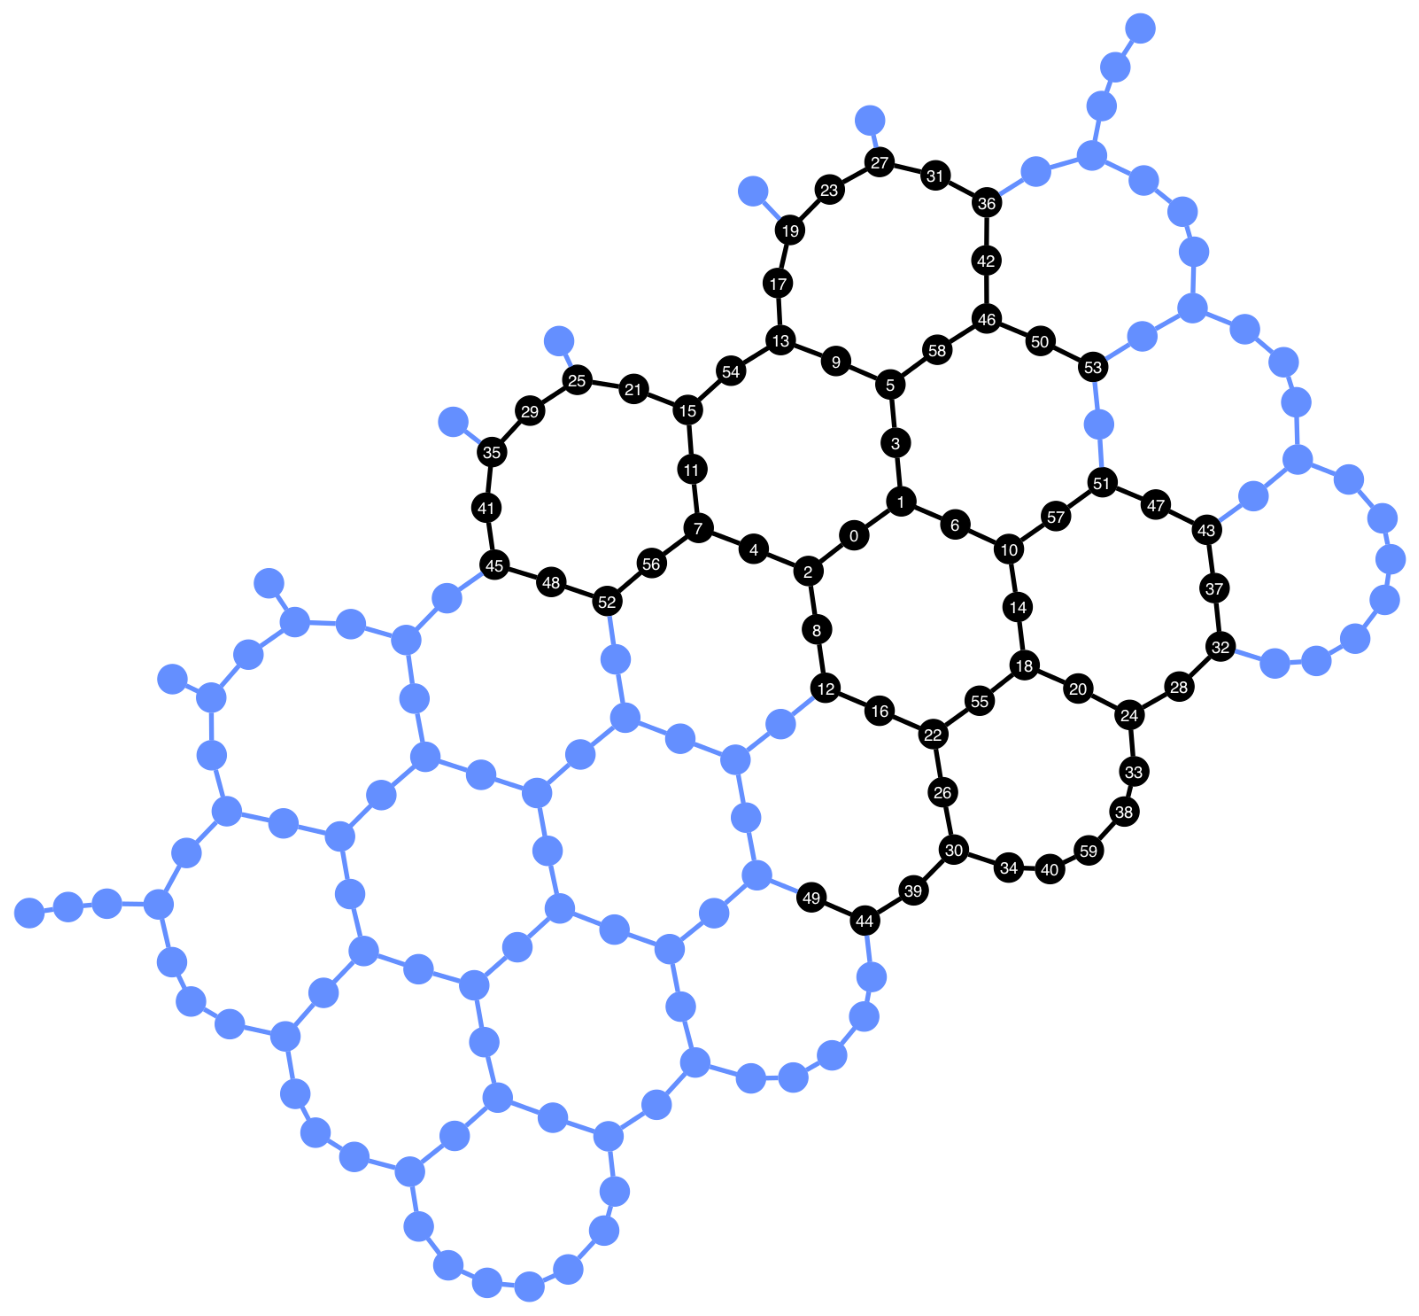

In [54]:
circuit = res['circuit_with_flags']
circ_lv3 = transpile(circuit, backend=backend, optimization_level=3, initial_layout=res['layout_with_flags'])
plot_circuit_layout(circ_lv3, backend)

In [46]:
def remove_elements(source_list, elements_to_remove):
    return [item for item in source_list if item not in elements_to_remove]

remove_elements(res['layout_with_flags'], res['layout_without_flags'])

[56, 58, 77, 38, 37, 59]

In [ ]:
from qiskit import QuantumCircuit, transpile
from ewfs.circuit import cnot_ladder, extract_qiskit_indices_by_prefix
from ewfs.observer import ALICE, BOB
from ewfs.strategy import MAJORITY_VOTE, RANDOM

def prepare_bipartite_system(qc: QuantumCircuit) -> None:
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(0)
    qc.x(1)
    qc.h(0)
    qc.cx(0, 1)

def apply_friend_state(qc: QuantumCircuit, charlie_size: int) -> QuantumCircuit:
    """Apply the state for the friends Charlie and Debbie."""

    charlie_qubits = [2+i for i in range(charlie_size)]

    # cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
    

    return qc

def apply_flag_operation(qc: QuantumCircuit, flag_qubits: list[int], charlie_size: int) -> None:
    """Apply the flag operation on Charlie's qubits."""
    charlie_qubits = [2+i for i in range(charlie_size)]
    for i, cq in enumerate(charlie_qubits):
        qc.cx(cq, flag_qubits[i % len(flag_qubits)])

In [70]:
backend = FakeFez()
coupling_map = backend.coupling_map

In [77]:
neighbors = coupling_map.neighbors(52)
for qubit in neighbors:
    print(qubit)

53
51


In [ ]:
layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]
layout_dict = dict(zip(layout, list(range(len(layout)))))

{53: 0,
 52: 1,
 51: 2,
 50: 3,
 49: 4,
 48: 5,
 47: 6,
 46: 7,
 45: 8,
 44: 9,
 43: 10,
 56: 11,
 63: 12,
 64: 13,
 65: 14,
 66: 15,
 67: 16,
 57: 17,
 68: 18,
 69: 19,
 70: 20,
 71: 21,
 58: 22}

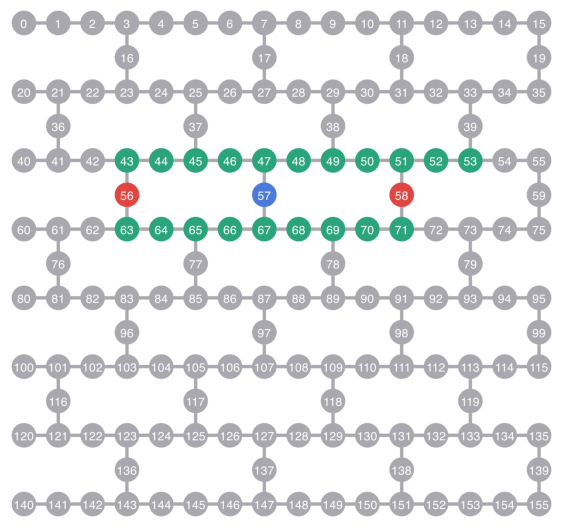

In [93]:
from ewfs.ghz import plot_ghz_fez

layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]

flags = [56, 58]

plot_ghz_fez(coupling_map=coupling_map, data_qubits=remove_elements(layout, flags), flag_qubits=flags, start_qubit=start_qubit)

[53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71]


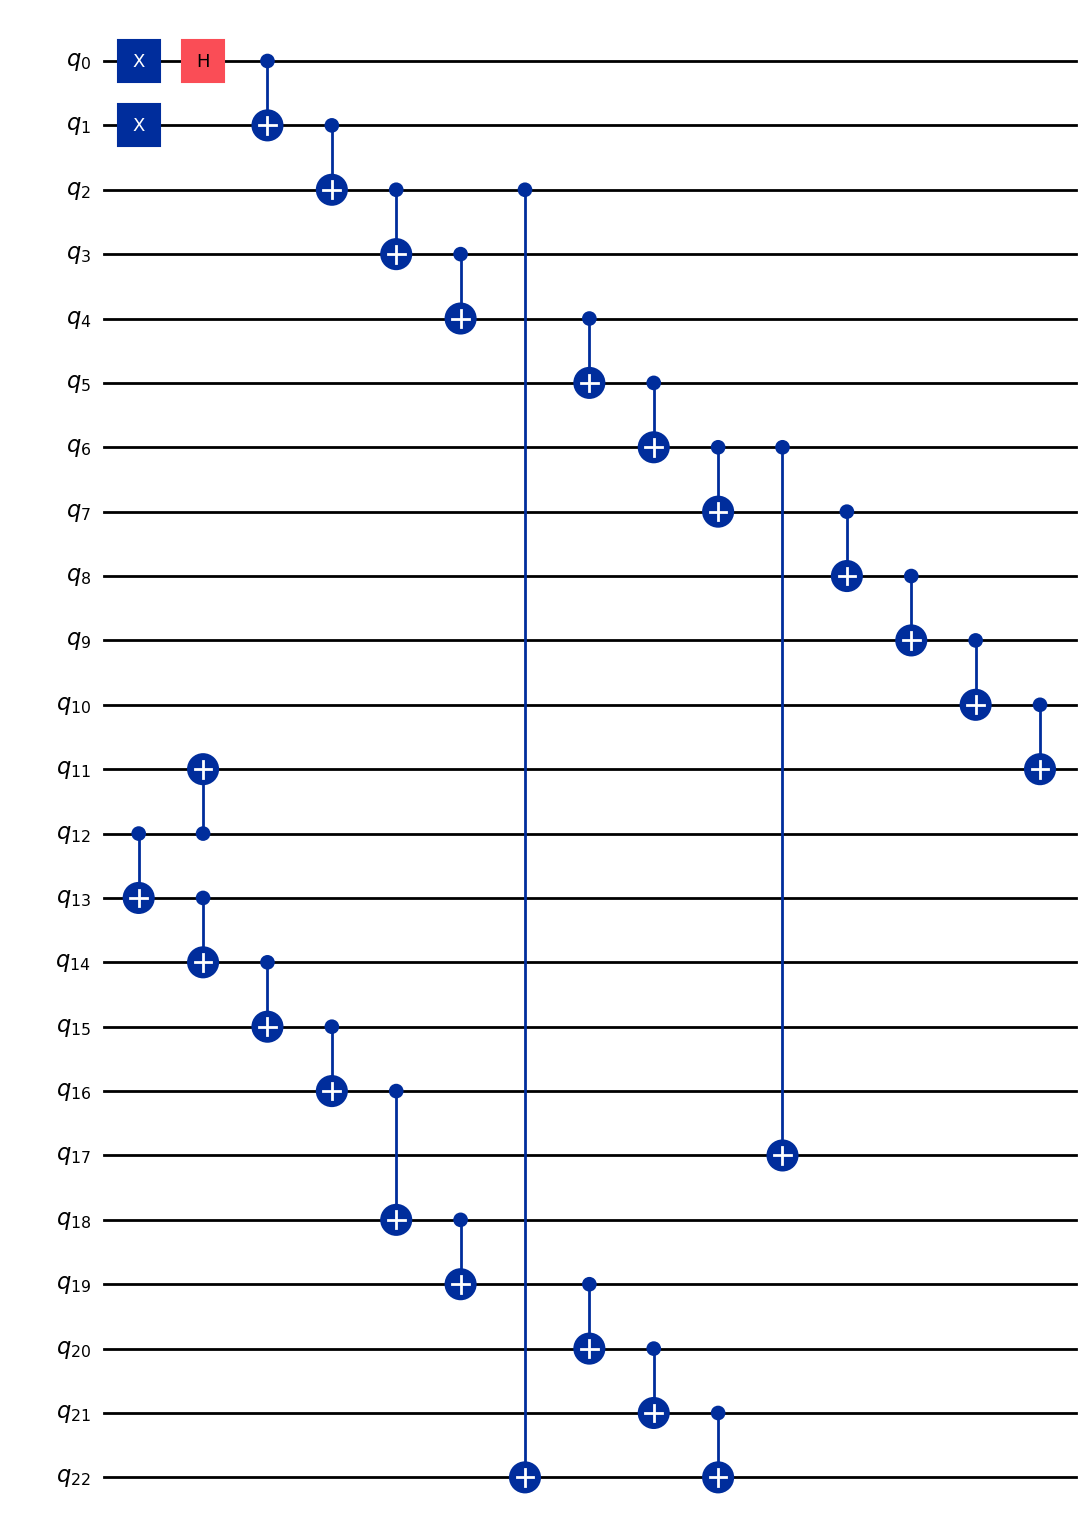

In [ ]:
from qiskit import QuantumCircuit


layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]

flags = [56, 58]


def initial_circuit_ewfs(layout, coupling_map):
    layout_dict = dict(zip(layout, range(len(layout))))
    qc = QuantumCircuit(len(layout))

    data_qubits = remove_elements(layout, flags)
    print(data_qubits)

    prepare_bipartite_system(qc)
    
    visited = [layout[0]]
    
    # first create the ghz state on the data qubits (layout\flags)
    for i in range(1, len(data_qubits)):
        neighbors = coupling_map.neighbors(data_qubits[i])
        for qubit in neighbors:
            if qubit not in visited and qubit in data_qubits:
                qc.cx(layout_dict[data_qubits[i]], layout_dict[qubit])
                visited.append(qubit)
        visited.append(data_qubits[i])

    # now implement the check operations
    for flag in flags:
        neighbors = coupling_map.neighbors(flag)
        for qubit in neighbors:
            qc.cx(layout_dict[qubit], layout_dict[flag])
    
    return qc


qc = initial_circuit_ewfs(layout, coupling_map)
qc.draw("mpl")

In [99]:
for flag in flags:
    print(flag, layout_dict[flag])

56 11
58 22
